In [49]:
import pandas as pd
!pip install seaborn
import seaborn as sns

In [50]:
food = pd.read_csv("food.csv", index_col=0)
# help(pd.read_csv)
     # zeigt die Dokumentation der Funktion pd.read_csv an

In [51]:
food.head()
# zeigt die ersten 5 Zeilen des DataFrames an


,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0


In [52]:
# check dimensions
food.shape
print("Anzahl Zeilen:", food.shape[0])  
print("Anzahl Spalten:", food.shape[1])

Anzahl Zeilen: 25
Anzahl Spalten: 9


In [53]:
# count missing values
food.isnull().sum()


RedMeat      0
WhiteMeat    0
Eggs         0
Milk         0
Fish         0
Cereals      0
Starch       0
Nuts         0
Fr.Veg       0
dtype: int64

In [54]:
# get feature statistics
food.describe()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,9.828000,7.896000,2.936000,17.112000,4.284000,32.248000,4.276000,3.072000,4.136000
std,3.347078,3.694081,1.117617,7.105416,3.402533,10.974786,1.634085,1.985682,1.803903
min,4.400000,1.400000,0.500000,4.900000,0.200000,18.600000,0.600000,0.700000,1.400000
25%,7.800000,4.900000,2.700000,11.100000,2.100000,24.300000,3.100000,1.500000,2.900000
50%,9.500000,7.800000,2.900000,17.600000,3.400000,28.000000,4.700000,2.400000,3.800000
75%,10.600000,10.800000,3.700000,23.300000,5.800000,40.100000,5.700000,4.700000,4.900000
max,18.000000,14.000000,4.700000,33.700000,14.200000,56.700000,6.500000,7.800000,7.900000


In [55]:
# Preprocess Data using z-transformation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
food_scaled = scaler.fit_transform(food) # array zurückgegeben

# convert the scaled data back to a DataFrame
food_scaled = pd.DataFrame(food_scaled, columns=food.columns, index=food.index)
# check the first few rows of the scaled data
food_scaled.head()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
Albania,0.082941,-1.794750,-2.224584,-1.179570,-1.225033,0.934804,-2.295965,1.247968,-1.378251
Austria,-0.282974,1.686446,1.245621,0.400468,-0.655111,-0.395051,-0.422218,-0.910790,0.092789
Belgium,1.119699,0.387905,1.062979,0.055732,0.064791,-0.525246,0.889405,-0.499598,-0.076947
Bulgaria,-0.618396,-0.523837,-1.220051,-1.265754,-0.925074,2.273959,-1.983674,0.322786,0.036210
Czechoslovakia,-0.039031,0.968104,-0.124197,-0.662467,-0.685107,0.190830,0.452198,-1.013588,-0.076947


In [56]:
# perform PCA
from sklearn.decomposition import PCA


# set n_components to 2 to extract PC1 and PC2
pca = PCA(n_components=2)
food_pca = pca.fit_transform(food_scaled)
# show the table of the PCA results
food_pca_df = pd.DataFrame(food_pca, columns=["PC1", "PC2"], index=food.index)
food_pca_df.head()
# show composition of PC1 and PC2 from food to understand which features contribute most to the variance
print("PCA Components (loadings):")
print(pca.components_)  


PCA Components (loadings):
[[-0.30260939 -0.31055622 -0.42667851 -0.37772728 -0.1356499   0.43774343
  -0.29724767  0.4203344   0.11041989]
 [-0.05625165 -0.23685334 -0.03533576 -0.18458877  0.6468197  -0.23348508
   0.35282564  0.14331056  0.53619004]]


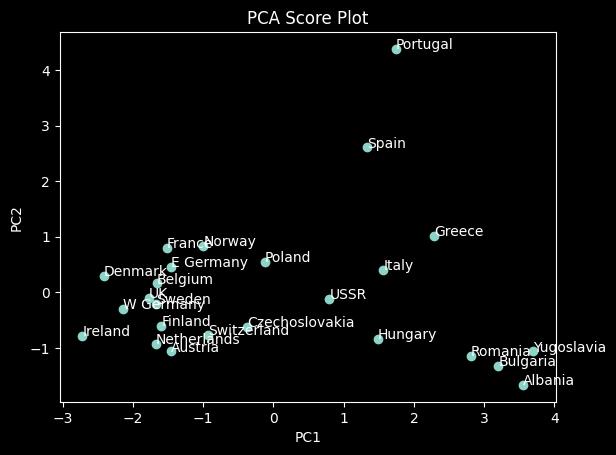

In [57]:
# create score plot

matplotlib.pyplot.scatter(food_pca[:, 0], food_pca[:, 1])
matplotlib.pyplot.xlabel("PC1")
matplotlib.pyplot.ylabel("PC2")
matplotlib.pyplot.title("PCA Score Plot")
# label points with country names
for i, country in enumerate(food.index):
    matplotlib.pyplot.annotate(country, (food_pca[i, 0], food_pca[i, 1]))
matplotlib.pyplot.show()



PC2 has a strong contribution of fish consuption: high in Portugal, Spain(?), Norway. 